# Exploratory Data Analysis (EDA)

In [53]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

In [2]:
# Load cleaned Dataset

df_accidents = pd.read_csv(
    "./data/processes/Kenya_road_accidents_cleaned.csv"
)

df_accidents.head()

,crash_id,crash_datetime,crash_date,latitude,longitude,n_crash_reports,contains_fatality_words,contains_pedestrian_words,contains_matatu_words,contains_motorcycle_words,year,month,month_name,day_name,hour
0,1,2018-06-06 20:39:54,2018-06-06,-1.263030,36.764374,1,0,0,0,0,2018,6,June,Wednesday,20
1,2,2018-08-17 06:15:54,2018-08-17,-0.829710,37.037820,1,1,0,0,0,2018,8,August,Friday,6
2,3,2018-05-25 17:51:54,2018-05-25,-1.125301,37.003297,1,0,0,0,0,2018,5,May,Friday,17
3,4,2018-05-25 18:11:54,2018-05-25,-1.740958,37.129026,1,0,0,0,0,2018,5,May,Friday,18
4,5,2018-05-25 21:59:54,2018-05-25,-1.259392,36.842321,1,1,0,0,0,2018,5,May,Friday,21


## Question 1: How have crashes changed over time?

In [3]:
# count crashes by year

crashes_by_year = df_accidents['year'].value_counts().sort_index()

crashes_by_year

year
2012     310
2013    1398
2014    4014
2015    6101
2016    4219
2017    3777
2018    4710
2019    2739
2020    1928
2021    1937
2022    1805
2023     721
Name: count, dtype: int64

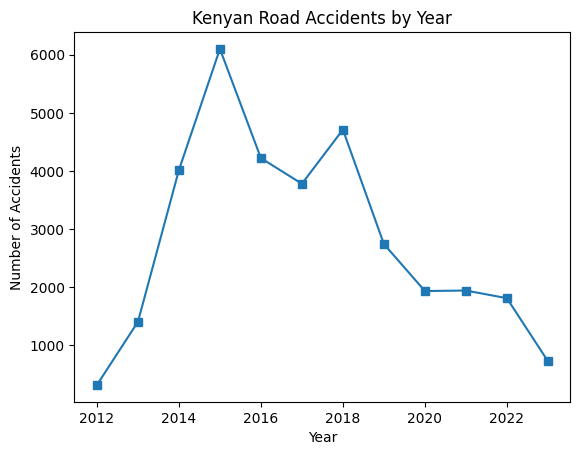

In [26]:
# visualize yearly trend

crashes_by_year.plot(
    kind='line',
    marker='s'
)

plt.title('Kenyan Road Accidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')


plt.savefig(
    "./images/crashes_by_year.png",
    bbox_inches='tight'
)

plt.show()


There was a steady increase in road accidents between 2015 and 2022, suggesting a growing traffic volume and increased reporting coverage as the years went by. 

## Question 2: Which months recorded the most crashes?

In [5]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
crashes_by_month = (
    df_accidents['month_name'].value_counts().reindex(month_order)
)

crashes_by_month

month_name
January      2673
February     2722
March        3206
April        2552
May          2999
June         2749
July         3030
August       2706
September    2632
October      2750
November     2867
December     2773
Name: count, dtype: int64

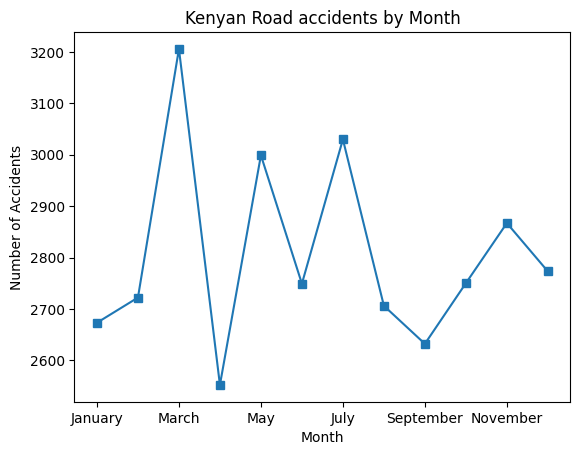

In [27]:
# plot crashes by month

crashes_by_month.plot(
    kind = 'line',
    marker = 's'
)

plt.title('Kenyan Road accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')

plt.savefig(
    "./images/crashes_by_month.png",
    bbox_inches='tight'
)

plt.show()

## Question 3: Which days are most dangerous?

In [7]:
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]
crashes_by_day = (
    df_accidents['day_name'].value_counts().reindex(weekday_order)
)

crashes_by_day

day_name
Monday       4976
Tuesday      5113
Wednesday    5008
Thursday     4941
Friday       5487
Saturday     4738
Sunday       3396
Name: count, dtype: int64

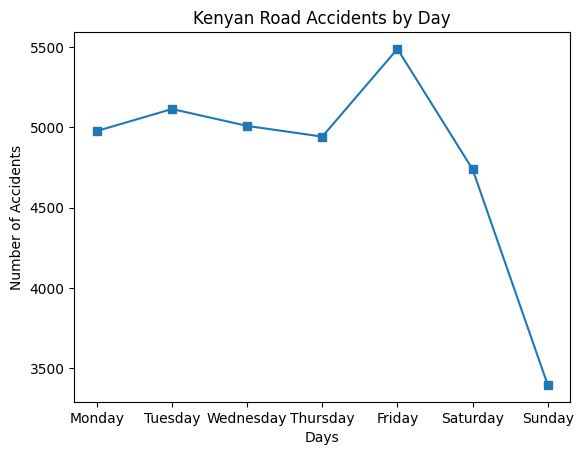

In [28]:
# plot Weekday Trend

crashes_by_day.plot(
    kind='line',
    marker='s',
)

plt.xlabel('Days')
plt.ylabel('Number of Accidents')
plt.title('Kenyan Road Accidents by Day')

plt.savefig(
    "./images/crashes_by_day.png",
    bbox_inches='tight'
)

plt.show()

## Question 4: Which hours are riskiest?

In [9]:

crashes_by_hour = df_accidents['hour'].value_counts().sort_index()

crashes_by_hour

hour
0      300
1      258
2      205
3      174
4      202
5      656
6     2890
7     3232
8     2322
9     1718
10    1482
11    1405
12    1334
13    1409
14    1481
15    1551
16    1715
17    2477
18    2210
19    1929
20    1876
21    1527
22     837
23     469
Name: count, dtype: int64

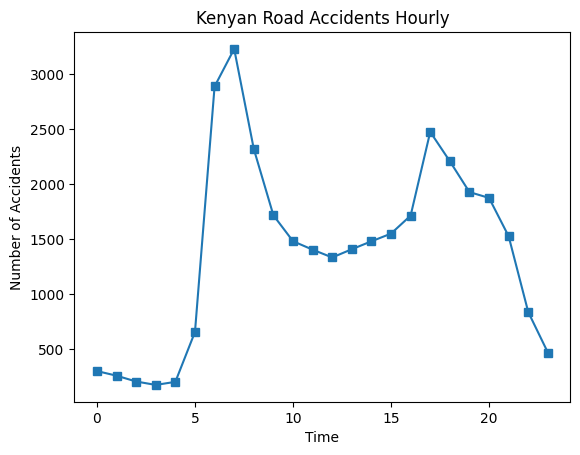

In [29]:
# plot hourly trend

crashes_by_hour.plot(
    kind='line',
    marker='s'
)

plt.xlabel('Time')
plt.ylabel('Number of Accidents')
plt.title('Kenyan Road Accidents Hourly')

plt.savefig(
    "./images/crashes_by_hour.png",
    bbox_inches='tight'
)

plt.show()

Most crashes occurred from 5 PM to 8 PM, corresponding to evening commuting periods.

## Question 5: What proportion of crashes involve fatalities?

In [11]:
df_accidents['contains_fatality_words'].value_counts()


contains_fatality_words
0    31209
1     2450
Name: count, dtype: int64

In [12]:
# percentage calculation
fatality_pct = df_accidents['contains_fatality_words'].mean()*100

fatality_pct

np.float64(7.278885290709766)

### Question 6: How common are pedestrian, motorcycle, and matatu crashes? 

In [13]:
# pedestrian crashes
df_accidents['contains_pedestrian_words'].value_counts()

contains_pedestrian_words
0    32654
1     1005
Name: count, dtype: int64

In [14]:
# pedestrian crashes percentage

pedestrian_pct = df_accidents['contains_pedestrian_words'].mean()*100

pedestrian_pct

np.float64(2.9858284559850263)

In [15]:
# Motorcycle crashes

df_accidents['contains_motorcycle_words'].value_counts()

contains_motorcycle_words
0    32422
1     1237
Name: count, dtype: int64

In [16]:
#motorcycle crashes percentage

motorcycle_pct = df_accidents['contains_motorcycle_words'].mean()*100

motorcycle_pct

np.float64(3.6750943284114204)

In [17]:
# Matatu crashes
df_accidents['contains_matatu_words'].value_counts()

contains_matatu_words
0    30909
1     2750
Name: count, dtype: int64

In [18]:
# Matatu crash percentage

matatu_pct = df_accidents['contains_matatu_words'].mean()*100
matatu_pct

np.float64(8.170177367123205)

## Question 7: Which locations experience the most crashes?

In [30]:
# find center of the data

center_latitude = df_accidents['latitude'].mean()

center_longitude = df_accidents['longitude'].mean()

center_latitude, center_longitude

(np.float64(-1.2723714267344661), np.float64(36.85319053971709))

Folium must have a starting point and average of the coordinates place the map near Nairobi, where most crash reports are concentrated.

In [40]:
# create a base map
kenyan_map = folium.Map(
    location=[center_latitude, center_longitude],
    zoom_start = 11
)

In [41]:
# display the map

kenyan_map

In [50]:
# add accident markers

sample_accidents_df = df_accidents.sample(
    150,
    random_state=42
)
sample_accidents_df.head()

,crash_id,crash_datetime,crash_date,latitude,longitude,n_crash_reports,contains_fatality_words,contains_pedestrian_words,contains_matatu_words,contains_motorcycle_words,year,month,month_name,day_name,hour
9301,9302,2012-12-16 14:37:32,2012-12-16,-1.318657,36.836364,1,0,0,0,0,2012,12,December,Sunday,14
32379,1662,2017-10-18 20:20:10,2017-10-18,-1.205178,36.915715,1,0,0,0,0,2017,10,October,Wednesday,20
31378,315,2018-07-28 19:39:24,2018-07-28,-1.330524,36.866639,1,0,0,0,0,2018,7,July,Saturday,19
20832,20833,2016-06-13 20:31:53,2016-06-13,-1.329937,36.871007,1,1,0,0,0,2016,6,June,Monday,20
24699,24700,2018-03-14 20:54:42,2018-03-14,-1.324723,36.896945,1,1,0,0,1,2018,3,March,Wednesday,20


In [51]:
for _, row in sample_accidents_df.iterrows():

    folium.CircleMarker(
        location=[
            row['latitude'],
            row['longitude']
        ],
        radius=3,
        fill=True
    ).add_to(kenyan_map)


kenyan_map

In [54]:
# creating a heat map
heatmap_data = df_accidents[
    ['latitude', 'longitude']
].values.tolist()

In [55]:
# create heat map
kenyan_heatmap = folium.Map(
    location=[
        center_latitude,
        center_longitude
    ],
    zoom_start=11
)

In [57]:
# add heat layer
HeatMap(
    heatmap_data
).add_to(
    kenyan_heatmap
)

In [58]:
kenyan_heatmap

Density visualization is displayed.

-Red = many crashes
-Yellow = moderate
-Blue = few

This helps reveal hotspots

In [61]:
# save the map
kenyan_heatmap.save(
    "./reports/kenya_accident_heatmap.html"
)

In [64]:
# identify top 20 hotspots

hotspots_top20 = (
    df_accidents.groupby(['latitude','longitude'])
    .size().reset_index(name='crash_count')
    .sort_values('crash_count', ascending=False)
)

hotspots_top20.head(20)

,latitude,longitude,crash_count
7406,-1.267441,36.835518,201
8577,-1.259367,36.843123,149
1474,-1.331398,36.888555,136
10235,-1.218637,36.891361,129
10733,-1.203744,36.917527,122
1659,-1.329937,36.871007,115
8417,-1.259975,36.843418,113
648,-1.395628,36.941025,104
6890,-1.274934,36.823417,102
3838,-1.300013,36.787803,97


In [65]:
# create hotspots markers
hotspot_kenyan_map = folium.Map(
    location=[
        center_latitude,
        center_longitude
    ],
    zoom_start=11
)

In [68]:
for _, row in hotspots_top20.head(20).iterrows():

    folium.Marker(
        location=[
            row['latitude'],
            row['longitude']
        ],
        popup=f"Crashes: {row['crash_count']}"
    ).add_to(
        hotspot_kenyan_map
    )

In [69]:
hotspot_kenyan_map

In [70]:
# save the hotspot map
hotspot_kenyan_map.save(
 "./reports/top_20_hotspots_map"
)

### Geospatial Analysis Findings

The heatmap reveals that road traffic crashes are highly concentrated in specific urban corridors and major transportation routes. Several hotspots exhibit significantly higher crash densities than surrounding areas, suggesting the need for targeted road safety interventions, traffic management improvements, and infrastructure upgrades.